# Testing the Waveform Generator [GPU]

This noteboook will serve as a quick way of testing if the WaveformModule for 1PAT1R is consistently passing what it should be to the amplitude, summation and trajectory modules.

This is a copy of the original notebook to test on GPU.

In [1]:
!nvidia-smi

Thu Apr 23 12:45:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:17:00.0 Off |                   On |
| N/A   34C    P0             44W /  300W |     249MiB /  81920MiB |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [2]:
!cd ../../FEW-dev/ && pwd && git log -1

/vsc-hard-mounts/leuven-data/367/vsc36785/LISA/FEW-dev
commit 3a30cfe374f0a31f433279876de643676b3c0b67 (HEAD -> 1PAT1R, origin/1PAT1R)
Author: BertDepoorter <bert@depoorter.name>
Date:   Fri Apr 17 17:58:57 2026 +0200

    Fix waveform on GPU


In [3]:
import numpy as np
import matplotlib.pyplot as plt

import few
setter = few.get_config_setter()
import os 
print(f'Available backends = {os.getenv('FEW_ENABLED_BACKENDS')}')

from few.waveform import Waveform1PAT1R, FastKerrEccentricEquatorialFlux

Available backends = None


In [4]:
# --- Define Parameters ---
m1 = 1e6       # primary mass [solar masses]
m2 = 10      # secondary mass [solar masses]
a  = 5*m2/m1       # primary spin chi1 (dimensionless)
p0 = 7.8     # initial orbital separation [M]
theta = np.pi / 3.0   # polar viewing angle [rad]
phi   = 0.0           # azimuthal viewing angle [rad]
chi2  = 0.1 # secondary spin

dt = 5.   # time step [s]
T  = 2    # total duration [yr]

In [5]:
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R

In [6]:
# --- Generate waveform ---
WF1PAT1R = Waveform1PAT1R()
h1PAT1R = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T)

h1PAT1Rzeropaamps = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T, zero_PA_amps_only=True)
h1PAT1Rnoprimary = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T, evolve_primary=False)


In [7]:
WF1PAT1R.xp

<module 'cupy' from '/data/leuven/367/vsc36785/miniconda3/envs/emri_env_ddpc/lib/python3.12/site-packages/cupy/__init__.py'>

In [8]:
h1PAT1R = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T)

In [15]:
WFKerr0PA = FastKerrEccentricEquatorialFlux()
hKerr = WFKerr0PA(m1, m2, a, p0, 0, 1,theta, phi, dt=dt, T=T)

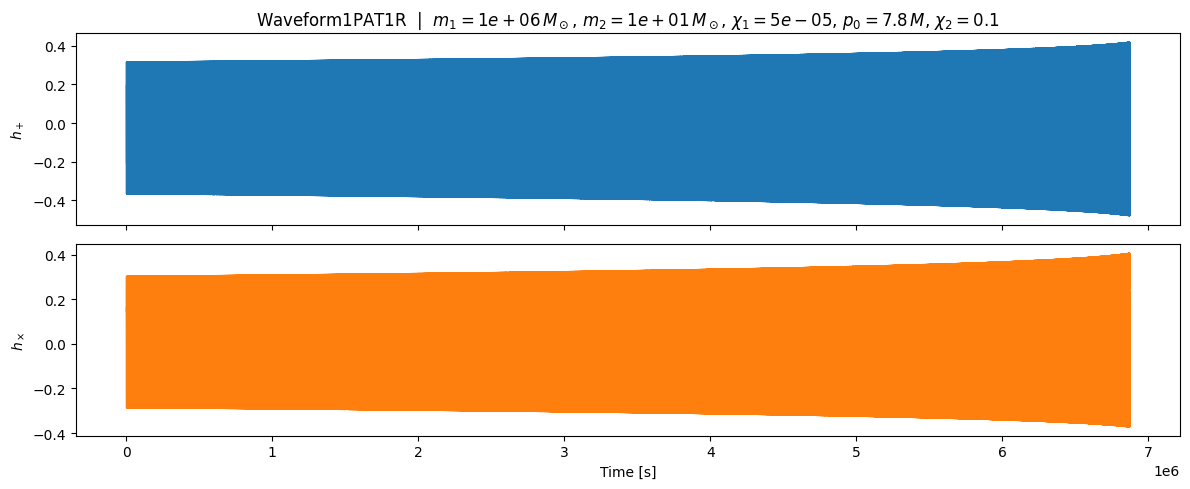

In [16]:
t1PA = np.arange(len(h1PAT1R)) * dt  # time array in seconds

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t1PA, h1PAT1R.real.get() if hasattr(h1PAT1R, 'get') else h1PAT1R.real, lw=0.8)
axes[0].set_ylabel(r"$h_+$")
axes[0].set_title(
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2:.0e}\,M_\odot$, "
    rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

axes[1].plot(t1PA, -h1PAT1R.imag.get() if hasattr(h1PAT1R, 'get') else -h1PAT1R.imag, lw=0.8, color="C1")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

In [17]:
# --- Generate comparison waveform ---
hKerr = WFKerr0PA(m1, m2, a, p0, 0, 1,theta, phi, dt=dt, T=T)
hKerr = WFKerr0PA(m1, m2, a, p0, 0, 1,theta, phi, dt=dt, T=T)

In [18]:
print(type(hKerr))

<class 'cupy.ndarray'>


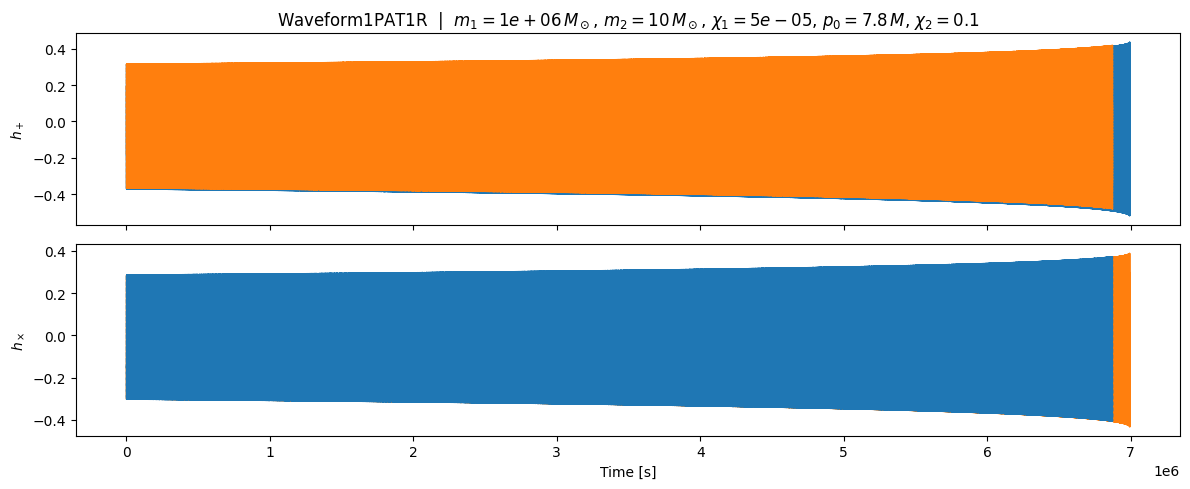

In [19]:
tKerr = np.arange(len(hKerr)) * dt  # time array in seconds
# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(tKerr, hKerr.real.get(), lw=0.8)
axes[0].plot(t1PA, h1PAT1R.real.get(), lw=0.8, ls="--", color="C1")
axes[0].set_ylabel(r"$h_+$")
axes[0].set_title(
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2}\,M_\odot$, "
    rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

axes[1].plot(tKerr, hKerr.imag.get(), lw=0.8, color="C1")
axes[1].plot(t1PA, h1PAT1R.imag.get(), lw=0.8, ls="--", color="C0")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

In [20]:
# get difference in time to ISCO
isco_0PA = len(hKerr)*dt 
isco_1PA = len(h1PAT1R)*dt
print(f'Time to ISCO differs with {np.abs(isco_1PA - isco_0PA) / 3600 / 24:.4e} days')

Time to ISCO differs with 1.3878e+00 days


In [21]:
# --- Define Parameters ---
m1 = 1e6       # primary mass [solar masses]
m2 = 10      # secondary mass [solar masses]
a  = 0.0       # primary spin chi1 (dimensionless)
p0 = 9.5      # initial orbital separation [M]
theta = np.pi / 3.0   # polar viewing angle [rad]
phi   = 0.0           # azimuthal viewing angle [rad]
chi2  = 0.0           # secondary spin

dt = 5.   # time step [s]
T  = 1    # total duration [yr]

In [22]:
from few.trajectory.inspiral import EMRIInspiral

# Note that for this test, I commented out all the 1PA order terms in Trajectory1PAT1R, 
# so this should be equivalent to a 0PA trajectory with the same parameters.
traj1PA = EMRIInspiral(func=Trajectory1PAT1R)

# EMRIInspiral expects: (m1, m2, a, p0, e0, xI, *extra_args, T=, dt=)
#   a    = chi1 (primary spin)
#   e0   = 0.0  (circular)
#   xI   = 1.0  (equatorial prograde)
#   chi2 = first extra arg -> additional_args[0] in Trajectory1PAT1R
t, p, e, xI_traj, Phi_phi, Phi_theta, Phi_r, dM, dchi1 = traj1PA(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    chi2,     # extra arg -> additional_args[0]
    T=T
)

print(f"Trajectory length: {len(t)} points")
print(f"p: {p[0]:.4f} -> {p[-1]:.4f} M")
print(f"Phi_phi: {Phi_phi[0]:.4f} -> {Phi_phi[-1]:.4f} rad")


Trajectory length: 26 points
p: 9.5000 -> 6.6517 M
Phi_phi: 0.0000 -> 262673.3794 rad


In [23]:
from few.trajectory.ode.flux import KerrEccEqFlux

In [24]:
traj0PA = EMRIInspiral(func=KerrEccEqFlux)


t2, p2, e2, xI_traj, Phi_phi2, Phi_theta2, Phi_r2 = traj0PA(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    T=T,
)

print(f"Trajectory length: {len(t2)} points")
print(f"p: {p2[0]:.4f} -> {p2[-1]:.4f} M")
print(f"Phi_phi: {Phi_phi2[0]:.4f} -> {Phi_phi2[-1]:.4f} rad")

Trajectory length: 26 points
p: 9.5000 -> 6.6514 M
Phi_phi: 0.0000 -> 262674.9311 rad


In [25]:
t[-1]

np.float64(31558149.76354559)

Trajectory length: 26 points
p: 9.5000 -> 6.6517 M
Phi_phi: 0.0000 -> 262673.3794 rad


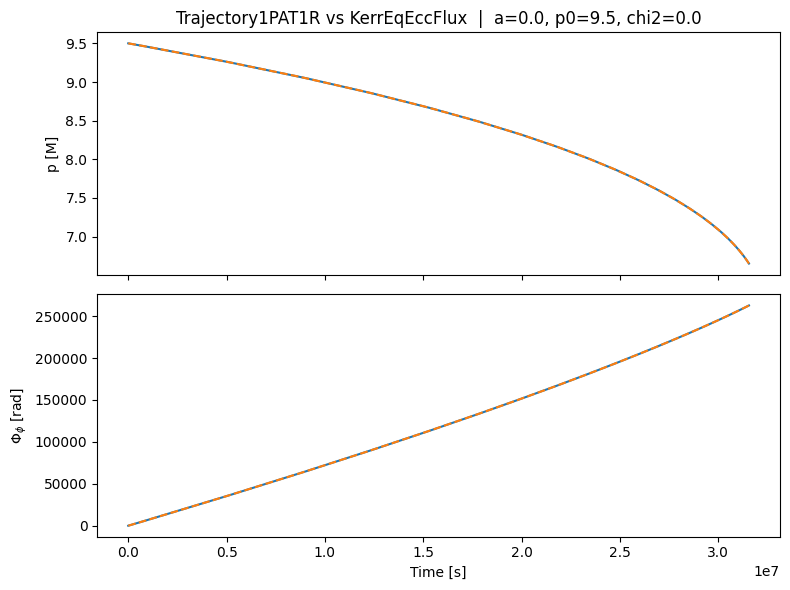

In [26]:
print(f"Trajectory length: {len(t)} points")
print(f"p: {p[0]:.4f} -> {p[-1]:.4f} M")
print(f"Phi_phi: {Phi_phi[0]:.4f} -> {Phi_phi[-1]:.4f} rad")

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(t, p)
axes[0].plot(t2, p2, linestyle="--")
axes[0].set_ylabel("p [M]")
axes[0].set_title(f"Trajectory1PAT1R vs KerrEqEccFlux  |  a={a}, p0={p0}, chi2={chi2}")
axes[1].plot(t, Phi_phi)
axes[1].plot(t2, Phi_phi2,linestyle="--")
axes[1].set_ylabel(r"$\Phi_\phi$ [rad]")
axes[1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()


In [27]:
from scipy.interpolate import CubicSpline
pSpline = CubicSpline(t2, p2)
p2Resampled = pSpline(t)


Phi_phiSpline = CubicSpline(t2, Phi_phi2)
Phi_phi2Resampled = Phi_phiSpline(t)


<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_816133/940555635.py:3: SyntaxWarning: invalid escape sequence '\D'
  axes[0].set_ylabel(" \Delta p [M]")


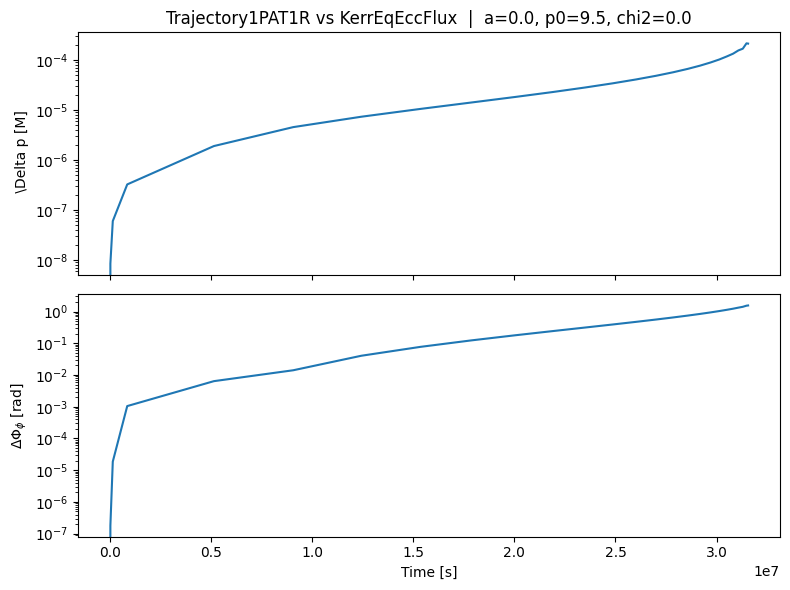

In [28]:

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(t, abs(p2Resampled-p))
axes[0].set_ylabel(" \Delta p [M]")
axes[0].set_yscale("log")
axes[0].set_title(f"Trajectory1PAT1R vs KerrEqEccFlux  |  a={a}, p0={p0}, chi2={chi2}")
axes[1].plot(t, abs(Phi_phi2Resampled-Phi_phi))
axes[1].set_yscale("log")
axes[1].set_ylabel(r"$ \Delta \Phi_\phi$ [rad]")
axes[1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

## Compute mismatch
Compute mismatch with white noise PSD. 
- Take waveform snapshots with equal length
- Apply window function to reduce spectral leakage when appl
- FFT waveforms for $h_+, h_\times$
- Compute mismatch $\mathcal(M)(h_1, h_2) = 1 - \frac{\langle h_1|h_2\rangle}{\sqrt{\langle h_1|h_1\rangle \langle h_2|h_2\rangle}}$ with $\langle h_1|h_2\rangle = 4\Re \int_{f_{min}}^{f_{max}} \frac{\tilde{h}_1(f) \tilde{h}_2(f)}{S_n(f)} df$. 

Boundaries are set to $f_{min} = 1e-5$ Hz, $f_{max} = 1 /(\Delta t)$ with $\Delta t$ the sampling cadence.

In [29]:
from scipy.signal.windows import tukey
import cupy as cp

# Align waveform lengths (take final N samples)
N = min(len(h1PAT1R), len(hKerr))
h1 = h1PAT1R[-N:]
h2 = hKerr[-N:]

window = cp.asarray(tukey(N, alpha=0.1))

h1_f = cp.fft.rfft(cp.asarray(h1.real) * window)
h2_f = cp.fft.rfft(cp.asarray(h2.real) * window)

freqs = cp.fft.rfftfreq(N, d=dt)
mask = (freqs > 1e-5) & (freqs < 1.0 / (2.0 * dt))

h1_f_inband = h1_f[mask]
h2_f_inband = h2_f[mask]

def inner_product_white(a, b):
    """Whitened inner product (flat PSD): real part of sum(a * conj(b))."""
    return cp.real(cp.nansum(a * cp.conj(b)))

def mismatch_white(h1_f, h2_f):
    ip_12 = inner_product_white(h1_f, h2_f)
    ip_11 = inner_product_white(h1_f, h1_f)
    ip_22 = inner_product_white(h2_f, h2_f)
    overlap = cp.abs(ip_12) / cp.sqrt(ip_11 * ip_22)
    return 1.0 - overlap

mm_white = mismatch_white(h1_f_inband, h2_f_inband)
print(f"Mismatch (white PSD): {float(mm_white):.4f}")

Mismatch (white PSD): 1.0000


In [30]:
def lisa_psd(f):
    """
    Analytic LISA noise PSD S_n(f) [1/Hz].
    Simplified SciRD model: test-mass + optical path noise.
    L = 2.5e9 m arm length.
    """
    L = 2.5e9          # arm length [m]
    c = 3e8            # speed of light [m/s]
    f_star = c / (2 * cp.pi * L)   # transfer frequency ~19.1 mHz

    # Test-mass acceleration noise
    S_acc = 9e-30 * (1 + (4e-4 / f)**2) * (1 + (f / 8e-3)**4)  # [m^2/s^4/Hz]

    # Optical metrology system (OMS) noise
    S_oms = 2.25e-22 * (1 + (2e-3 / f)**4)  # [m^2/Hz]

    # Combined TDI-X PSD
    Sn = (20 / 3) * (S_oms / L**2 + 2 * S_acc / (2 * cp.pi * f)**4 / L**2) \
         * (1 + (f / f_star)**2)
    return Sn

def inner_product_lisa(a, b, psd):
    """PSD-weighted inner product: real(sum(a * conj(b) / S_n(f)))."""
    return cp.real(cp.nansum(a * cp.conj(b) / psd))

def mismatch_lisa(h1_f, h2_f, freqs_inband):
    psd = lisa_psd(freqs_inband)
    ip_12 = inner_product_lisa(h1_f, h2_f, psd)
    ip_11 = inner_product_lisa(h1_f, h1_f, psd)
    ip_22 = inner_product_lisa(h2_f, h2_f, psd)
    overlap = cp.abs(ip_12) / cp.sqrt(ip_11 * ip_22)
    return 1.0 - overlap

freqs_inband = freqs[mask]

mm_lisa = mismatch_lisa(h1_f_inband, h2_f_inband, freqs_inband)
print(f"Mismatch (LISA PSD):  {float(mm_lisa):.6f}")

Mismatch (LISA PSD):  0.999995


Text(0, 0.5, 'Strain $|\\tilde{h}(f)|$')

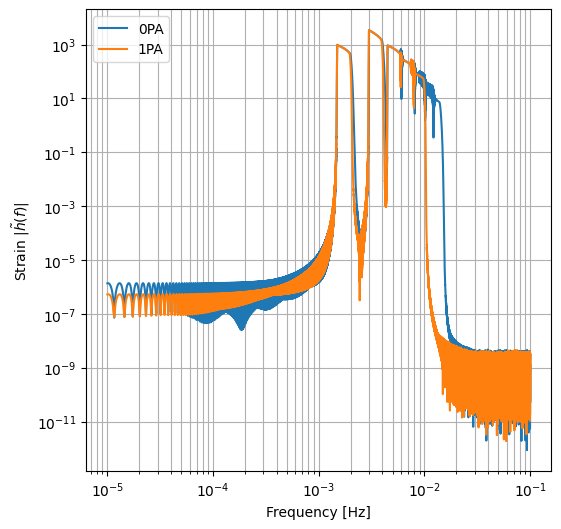

In [31]:
# Plot FD realizations

fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.loglog(freqs_inband.get(), np.abs(h2_f_inband.get()), label='0PA')
ax.loglog(freqs_inband.get(), np.abs(h1_f_inband.get()), label='1PA')
ax.grid(True, which='both')
ax.legend(loc='upper left')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'Strain $|\tilde{h}(f)|$')

Careful with interpretation here: Waveforms have not been aligned in time or phase-maximized to obtain the optimal overlap. It may be more instructive to take two waveforms with equal starting parameters, and then track the evolution of the mismatch as we compute the fft over a longer stretch of time. 

## Test with Mojito Heavy proposed sources
These are in another repo. Load the csv file and check if model works. 

In [9]:
# def path
import os
cat_path = f'{os.getcwd()}/../../MojitoHeavy/wavelet_SNR_quasicircular_cat.csv'

# load cat as dataframe
import pandas as pd
sources_sp = pd.read_csv(cat_path)

In [10]:
sources_sp = sources_sp.set_index('source_index')
sources_sp

,Unnamed: 0,snr_catalog,snr_MojitoL,snr_wavelet,M_results,e0_results,p0_results,a_results,z_results,Tgw_results,...,p0_det,p4,phiK,phiS,qK,qS,t_back,x_f,z_det,SNR_MojitoL
source_index,,,,,,,,,,,,,,,,,,,,,
203,5,33.197902,18.380150,3.360983,1.629671e+06,0.0,8.185091,-0.000037,1.4988,1.248293,...,5.503523,2.110485,6.150153,0.457351,2.847214,0.955699,0.533873,0.828092,1.4988,18.380150
351,7,27.292762,23.278914,29.886948,1.253141e+05,0.0,26.388158,-0.000617,1.3537,1.478666,...,26.991347,5.298220,3.652192,2.930067,2.185336,1.903380,1.675241,0.052336,1.3537,23.278914
421,9,40.094446,34.657857,47.642405,2.873426e+05,0.0,17.585849,0.000056,0.5960,1.820011,...,11.933654,1.797849,5.031627,0.383603,0.639737,2.258354,0.509135,0.992010,0.5960,34.657857
699,14,33.226379,26.033266,85.059218,4.383288e+05,0.0,12.263378,0.000022,0.2198,1.327745,...,13.565884,7.329899,4.039823,4.707806,0.724733,1.070639,1.810535,-0.483110,0.2198,26.033266
1453,21,22.780586,18.192219,16.026459,1.247096e+06,0.0,9.253727,0.000032,0.3357,1.784473,...,7.279217,4.134921,1.020935,5.736937,1.570867,0.306803,1.168532,0.340827,0.3357,18.192219
1561,23,41.897537,44.209450,27.070915,3.653423e+05,0.0,15.787379,-0.000002,1.7266,1.714912,...,11.345526,9.011598,2.924618,1.935320,0.159050,0.441768,0.149641,-0.912520,1.7266,44.209450
1999,32,46.351615,45.221238,41.596753,9.101228e+04,0.0,35.377821,0.000076,1.5214,1.334567,...,22.530523,9.011847,2.680195,2.810142,1.160156,1.272172,0.163998,-0.949990,1.5214,45.221238
3062,51,20.166123,21.942579,8.361723,4.411639e+05,0.0,11.154599,0.000027,2.2311,1.990534,...,8.466378,7.480538,5.027174,1.906283,0.954350,1.656833,0.188098,-0.476354,2.2311,21.942579
3069,52,26.027248,40.395510,15.543676,4.185044e+05,0.0,12.312953,0.000082,1.1531,1.345185,...,10.813570,1.636899,2.513501,6.060069,1.080561,2.578224,1.345789,0.964961,1.1531,40.395510


In [11]:
sources_sp.keys()

Index(['Unnamed: 0', 'snr_catalog', 'snr_MojitoL', 'snr_wavelet', 'M_results',
       'e0_results', 'p0_results', 'a_results', 'z_results', 'Tgw_results',
       'M_det', 'Phi_phi0', 'Phi_r0', 'Phi_theta0', 'R_LSO', 'SNR', 'Tgw_det',
       'Y0', 'Y4', 'Y_f', 'a_det', 'dist', 'e0_det', 'e4', 'e_f', 'error',
       'inc_f', 'max_f', 'min_f', 'mu', 'n_bin', 'p0_det', 'p4', 'phiK',
       'phiS', 'qK', 'qS', 't_back', 'x_f', 'z_det', 'SNR_MojitoL'],
      dtype='str')

In [12]:
# build FEW parameter vector with the parameters labelled _results. 
# spins, eccentricities and p0 have been regenerated.

def get_few_vector(source_index):
    # Draw secondary spin randomly between +/-0.999 
    chi2 = np.random.uniform(-0.999, 0.999)
    #m1, m2, a, p0, theta, phi, chi2
    few_vector = [
        sources_sp.M_results[source_index],
        sources_sp.mu[source_index],
        sources_sp.a_results[source_index],
        sources_sp.p0_results[source_index],
        sources_sp.qS[source_index],
        sources_sp.phiS[source_index],
        chi2
    ]
    return few_vector

In [14]:
# Loop over generated sources adn check if waveform runs
# while we're at it, compute mismatch with 0PA model
for idx, source_index in enumerate(sources_sp.index.tolist()):
    params = get_few_vector(source_index)
    try:
        h_1PA = WF1PAT1R(*params, dt=5, T=2)
        print(f'Source {source_index} succcesful')
    except Exception as e:
        print(f'Source {source_index} failed: {e}')
        print(f'Failed source has p0 = {params[3]}')
        # Rerun with p0 capped at 29.9
        params[3] = 29.9
        try:
            h_1PA = WF1PAT1R(*params, dt=5, T=2)
            print(f'Source {source_index} succcesful on second try')
        except Exception as e:
            print(f'Source {source_index} failed: {e}')
    
    # compute mismatch against 0PA model
    

Source 203 succcesful
Source 351 succcesful
Source 421 succcesful
Source 699 succcesful
Source 1453 succcesful
Source 1561 succcesful
Source 1999 failed: Interpolation: p out of bounds. Must be between 6.25 and 30.0.
Failed source has p0 = 35.37782075561835
Source 1999 succcesful on second try
Source 3062 succcesful
Source 3069 succcesful
Source 3429 succcesful
Source 3442 succcesful
Source 3824 succcesful
Source 4005 succcesful
Source 4529 succcesful
Source 4654 succcesful
Source 4692 succcesful
Source 4847 succcesful
Source 5476 succcesful
Source 5594 succcesful
Source 6237 failed: Interpolation: p out of bounds. Must be between 6.25 and 30.0.
Failed source has p0 = 32.15320787998013
Source 6237 succcesful on second try
Source 6458 succcesful
Source 6477 succcesful
Source 7187 succcesful
Source 7530 succcesful
Source 8083 succcesful
Source 8303 succcesful
Source 8805 succcesful
Source 8926 succcesful
Source 9005 succcesful
Source 9344 succcesful
Source 9904 succcesful
Source 10483 su

We have something working for 46 out of 48 sources. That's good, we can proceed with those 46. 

### First draft of source selection
We have chosen some sources in the other notebook. Check parameter distributions

In [15]:
# Picked some sources as a first cut. 
Good_sources = [
    351, 421, 699, 15833, 12642, 
    13749, 10483, 9005, 1999, 4847, 
    11869, 12806, 15078, 6237, 7187
]

# compute secondary spins for all sources 
chi2_vals = np.random.uniform(-0.999, 0.999, size=len(Good_sources))


In [26]:
cat_selected = sources_sp.loc[Good_sources]

In [30]:
cat_selected[['snr_wavelet', 'M_results', 'mu', 'z_results', 'p0_results', 'Tgw_results', 'a_results', 'e0_results', 'dist']]

,snr_wavelet,M_results,mu,z_results,p0_results,Tgw_results,a_results,e0_results,dist
source_index,,,,,,,,,
351,29.886948,125314.117494,34.865122,1.3537,26.388158,1.478666,-0.000617,0.0,9.609491
421,47.642405,287342.588667,17.680306,0.5960,17.585849,1.820011,0.000056,0.0,3.501463
699,85.059218,438328.793419,7.794991,0.2198,12.263378,1.327745,0.000022,0.0,1.089433
15833,20.079369,423642.966050,11.742217,0.4835,13.894646,1.864350,0.000059,0.0,2.721154
12642,35.041876,291272.846483,15.837624,1.1594,14.938458,1.342007,0.000151,0.0,7.933474
13749,16.907793,95895.891291,19.881620,0.9977,27.581642,1.549228,-0.000867,0.0,6.588273
10483,66.587404,166724.721255,8.321856,0.1721,19.194243,1.406549,0.000219,0.0,0.829447
9005,28.014520,251304.346436,7.329065,0.7972,14.651305,1.639571,-0.000143,0.0,4.995850
1999,41.596753,91012.281203,73.300803,1.5214,35.377821,1.334567,0.000076,0.0,11.100566


Increase SNR of everythong to above 20

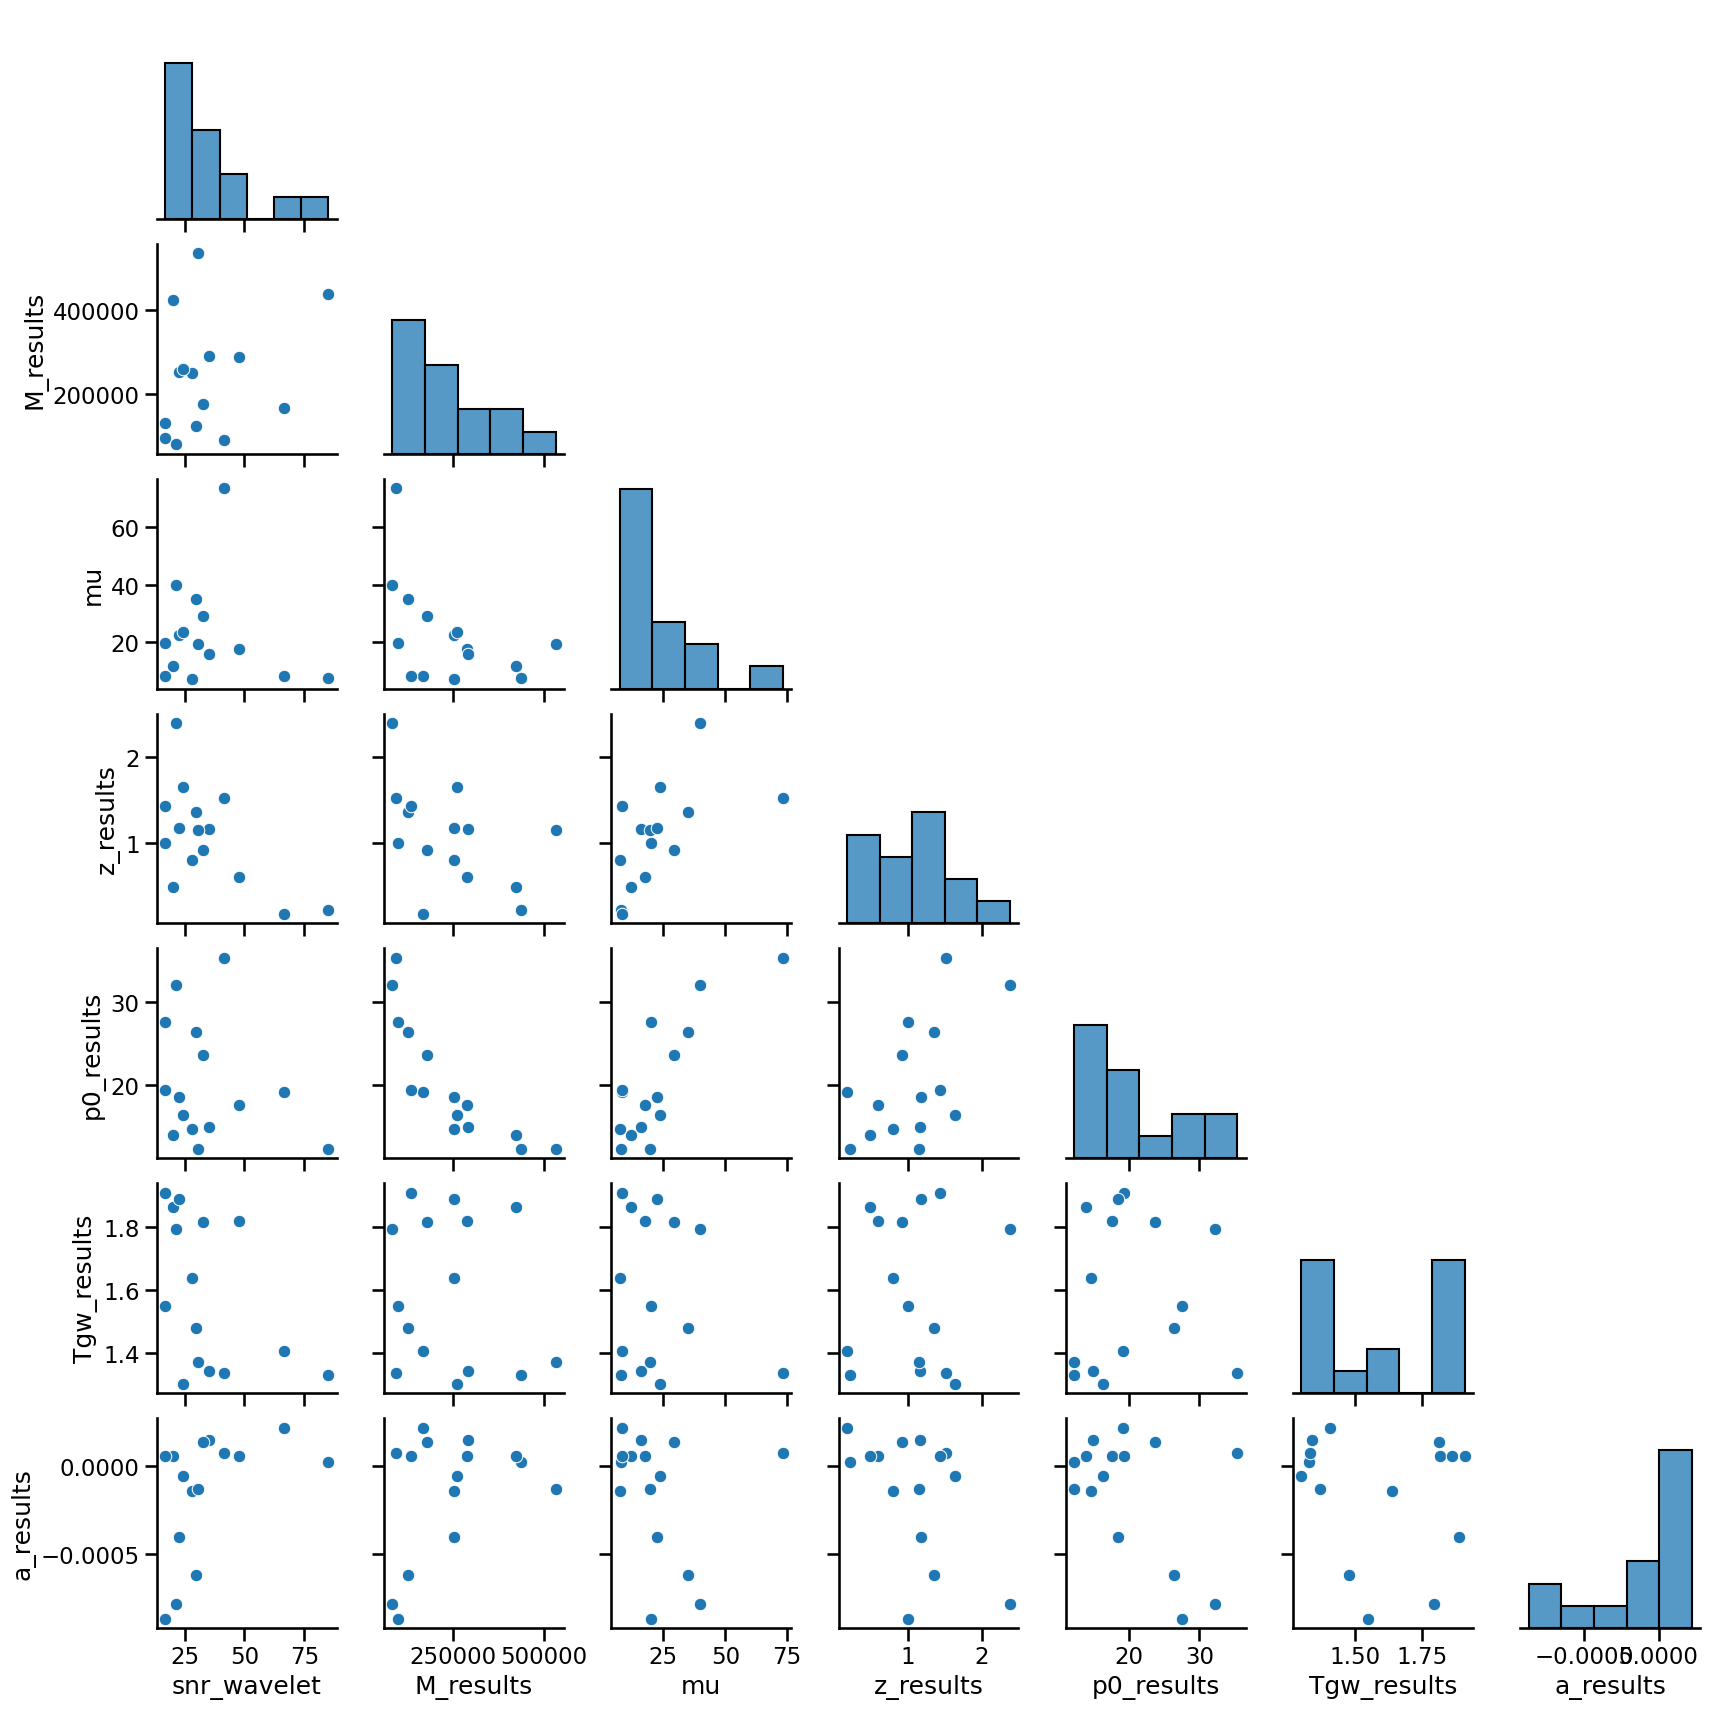

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_cols = ['snr_wavelet', 'M_results', 'mu', 'z_results', 'p0_results', 'Tgw_results', 'a_results']
sns.set_context("talk")
sns.pairplot(cat_selected[plot_cols], corner=True, diag_kind='hist')

plt.show()

Text(0, 0.5, '$\\log(\\mu / M_\\odot)$')

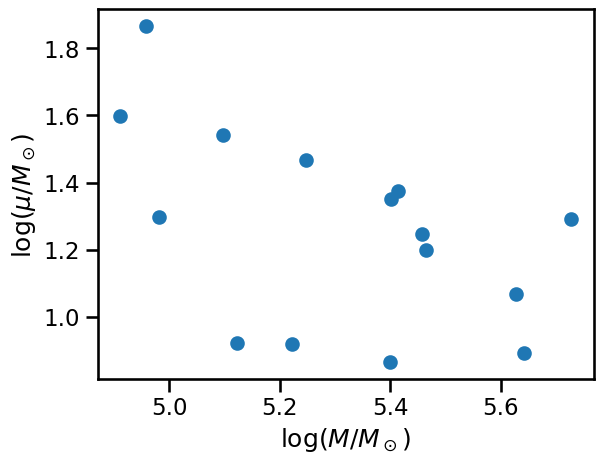

In [37]:
# Plot mass ratio's
plt.scatter(np.log10(cat_selected['M_results']), np.log10(cat_selected['mu']))
plt.xlabel(r'$\log(M / M_\odot)$')
plt.ylabel(r'$\log(\mu / M_\odot)$')

In [39]:
np.log10(cat_selected['mu'] / cat_selected['M_results'])

source_index
351     -3.555609
421     -4.210910
699     -4.749984
15833   -4.557250
12642   -4.264610
13749   -3.683348
10483   -4.301780
9005    -4.535151
1999    -3.093991
4847    -3.782199
11869   -4.199459
12806   -4.436338
15078   -4.049087
6237    -3.312507
7187    -4.039210
dtype: float64